# 14 — Fibonacci, Swings and Pivot Points

## What you'll learn
- How to find **swing highs and lows** — the turning points every level is measured from — and why they are confirmed *after* the fact.
- What **Fibonacci retracement** levels are (`23.6%`, `38.2%`, `50%`, `61.8%`, `78.6%`) and how they are computed from a single up-leg.
- What **Fibonacci extensions** (`127.2%`, `161.8%`, `200%`) add: price targets *beyond* the swing high.
- How **classic pivot points** (P, R1–R3, S1–S3) turn yesterday's high/low/close into today's support and resistance.
- How traders turn all three into **entry, stop and target** — as zones to watch, never as predictions.

Everything is computed by `stocklearn.indicators` from ordinary OHLCV bars: no charting library, no
"levels" package, no black box.

## Setup

Same pattern as every notebook: one `ticker`, one `period` at the top. Six months is a good compromise — long
enough to contain a real swing leg, short enough that the levels still matter today.

In [1]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from stocklearn.data import get_history, price_series
from stocklearn.indicators import (
    fibonacci_extensions,
    fibonacci_levels,
    pivot_points,
    recent_swing,
    swing_highs_lows,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

ticker = "AAPL"
period = "6mo"
window = 5

## 1. Swings — where price actually turned

A **swing high** is a bar whose close is higher than the closes of the `window` bars on either side of it; a
**swing low** is lower than all of them. With `window=5` each candidate is compared against 11 bars, so a
"turn" has to be visible on the chart, not a one-day wiggle.

Two consequences worth holding on to:

- **Swings are confirmed late.** The last `window` bars can never qualify, because we cannot yet see what
  comes after them. A swing high is a historical fact, not a live signal.
- **Ties are ignored.** The test is a *strict* maximum/minimum, so a flat stretch produces no swing at all —
  better than picking an arbitrary bar out of a plateau.

`swing_highs_lows` returns one row per bar, mostly `NaN`, with the extreme where it was found:

In [2]:
df = get_history(ticker, period=period)
close = price_series(df)          # adjusted close

sw = swing_highs_lows(close, window=window)

highs = sw["high"].dropna()
lows = sw["low"].dropna()
print(f"{len(close)} bars | {len(highs)} swing highs | {len(lows)} swing lows")

print("\nlast 4 swing highs:")
print(highs.tail(4).rename("close").to_frame().assign(date=highs.tail(4).index.date))
print("\nlast 4 swing lows:")
print(lows.tail(4).rename("close").to_frame().assign(date=lows.tail(4).index.date))

126 bars | 8 swing highs | 6 swing lows

last 4 swing highs:
                           close        date
Date                                        
2026-07-28 00:00:00-04:00 339.79  2026-07-28
2026-08-07 00:00:00-04:00 313.06  2026-08-07
2026-08-19 00:00:00-04:00 316.83  2026-08-19
2026-09-25 00:00:00-04:00 341.07  2026-09-25

last 4 swing lows:
                           close        date
Date                                        
2026-07-23 00:00:00-04:00 321.38  2026-07-23
2026-08-03 00:00:00-04:00 303.16  2026-08-03
2026-08-12 00:00:00-04:00 302.25  2026-08-12
2026-09-09 00:00:00-04:00 315.34  2026-09-09


`recent_swing` reduces that to the one leg we measure levels from: the **last swing high** and the **last swing
low that came before it** — a completed up-move. It returns positions (not labels), so the dates come from
`close.index`:

In [3]:
leg = recent_swing(close, window=window)
print(leg)

low_date = close.index[leg["low_bar"]].date()
high_date = close.index[leg["high_bar"]].date()
print(f"\nleg: {low_date} @ {leg['low']:,.2f}  →  {high_date} @ {leg['high']:,.2f}")
print(f"span: {leg['high'] - leg['low']:,.2f} points  ({(leg['high'] / leg['low'] - 1) * 100:,.1f}%)")

{'low': 315.3399963378906, 'high': 341.07000732421875, 'low_bar': 108, 'high_bar': 120}

leg: 2026-09-09 @ 315.34  →  2026-09-25 @ 341.07
span: 25.73 points  (8.2%)


## 2. Fibonacci retracement

A retracement asks: *if price pulls back into this up-leg, where might buyers step in?* The classic answer is
a few ratios of the leg's height, measured **down from the high**:

$$
\text{level}(r) = \text{high} - r \cdot (\text{high} - \text{low})
\qquad r \in \{0.236,\ 0.382,\ 0.5,\ 0.618,\ 0.786\}
$$

`0.0` is the high, `1.0` the low. The `0.382`–`0.618` band is the famous "golden pocket", and `0.618` is the
golden ratio itself (roughly $1/\varphi$). Treat the levels as **zones to watch**, not as magnets: enough
traders look at them for them to be self-fulfilling sometimes and ignored other times.

In [4]:
levels = fibonacci_levels(leg["low"], leg["high"])

label = {"0.0": "0.0%  (high)", "0.236": "23.6%", "0.382": "38.2%", "0.5": "50.0%",
         "0.618": "61.8%", "0.786": "78.6%", "1.0": "100%  (low)"}
fib_table = pd.DataFrame(
    {"ratio": list(levels), "price": list(levels.values())}, index=[label[r] for r in levels]
)
fib_table["vs last close"] = fib_table["price"] - close.iloc[-1]
print(f"last close: {close.iloc[-1]:,.2f}\n")
fib_table

last close: 333.69



,ratio,price,vs last close
0.0% (high),0.0,341.07,7.38
23.6%,0.236,335.00,1.31
38.2%,0.382,331.24,-2.45
50.0%,0.5,328.21,-5.49
61.8%,0.618,325.17,-8.52
78.6%,0.786,320.85,-12.84
100% (low),1.0,315.34,-18.35


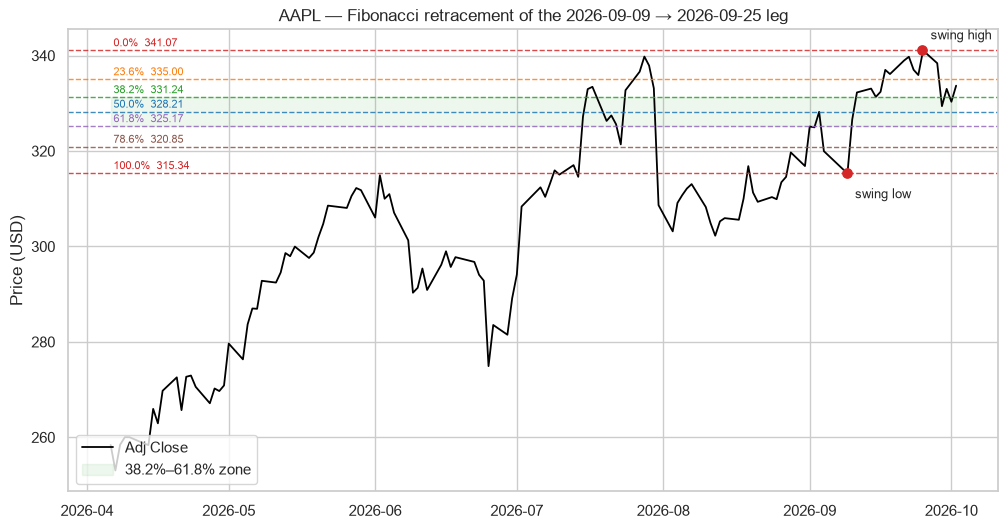

In [5]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(close.index, close, color="black", lw=1.3, label="Adj Close")

colors = {"0.0": "tab:red", "0.236": "tab:orange", "0.382": "tab:green", "0.5": "tab:blue",
          "0.618": "tab:purple", "0.786": "tab:brown", "1.0": "tab:red"}
for ratio, price in levels.items():
    ax.axhline(price, color=colors[ratio], lw=1.0, ls="--", alpha=0.85)
    ax.annotate(f"{float(ratio) * 100:.1f}%  {price:,.2f}", xy=(close.index[0], price),
                xytext=(2, 3), textcoords="offset points", fontsize=8, color=colors[ratio])

ax.fill_between([close.index[0], close.index[-1]], levels["0.618"], levels["0.382"],
                color="tab:green", alpha=0.08, label="38.2%–61.8% zone")

ax.scatter([low_date, high_date], [leg["low"], leg["high"]], color="tab:red", zorder=3, s=45)
ax.annotate("swing low", (low_date, leg["low"]), xytext=(6, -18), textcoords="offset points", fontsize=9)
ax.annotate("swing high", (high_date, leg["high"]), xytext=(6, 8), textcoords="offset points", fontsize=9)

ax.set_title(f"{ticker} — Fibonacci retracement of the {low_date} → {high_date} leg")
ax.set_ylabel("Price (USD)")
ax.legend(loc="lower left")
plt.show()

## 3. Extensions — targets beyond the high

Retracement levels all sit *inside* the leg. **Extensions** project the leg's height beyond the high, which is
where traders put profit targets when the up-move resumes:

$$
\text{extension}(r) = \text{high} + (r - 1) \cdot (\text{high} - \text{low})
\qquad r \in \{1.272,\ 1.618,\ 2.0,\ 2.618\}
$$

`1.0` is the high itself; `1.618` is one golden-ratio span above it. Both functions are pure arithmetic on two
numbers — the interesting part is *which* two numbers you feed them, which is exactly what `recent_swing` decides.

In [6]:
extensions = fibonacci_extensions(leg["low"], leg["high"])
ext_table = pd.DataFrame(
    {"ratio": list(extensions), "price": list(extensions.values())},
    index=["100%  (high)", "127.2%", "161.8%", "200%", "261.8%"],
)
ext_table["vs last close"] = ext_table["price"] - close.iloc[-1]
ext_table

,ratio,price,vs last close
100% (high),1.0,341.07,7.38
127.2%,1.272,348.07,14.38
161.8%,1.618,356.97,23.28
200%,2.0,366.80,33.11
261.8%,2.618,382.70,49.01


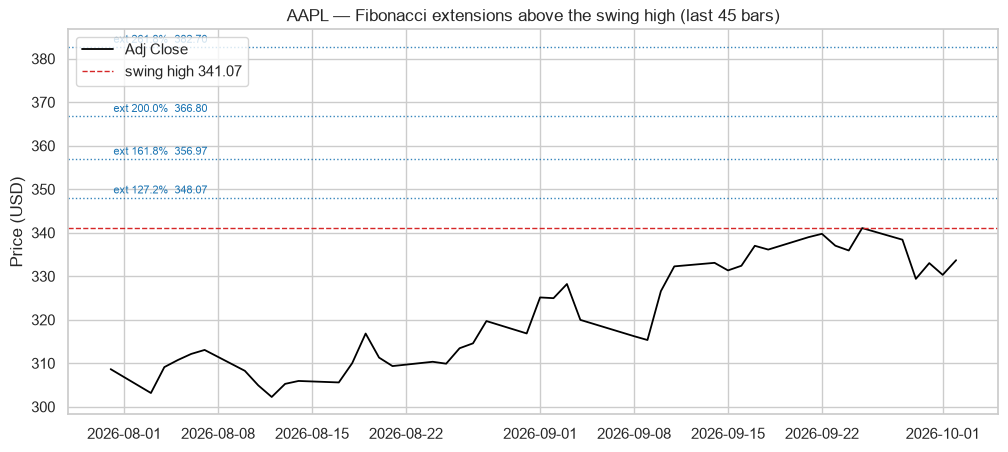

In [7]:
recent = close.iloc[-45:]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(recent.index, recent, color="black", lw=1.3, label="Adj Close")
ax.axhline(leg["high"], color="tab:red", lw=1.0, ls="--", label=f"swing high {leg['high']:,.2f}")

for ratio, price in extensions.items():
    if ratio == "1.0":
        continue
    ax.axhline(price, color="tab:blue", lw=1.0, ls=":", alpha=0.9)
    ax.annotate(f"ext {float(ratio) * 100:.1f}%  {price:,.2f}", xy=(recent.index[0], price),
                xytext=(2, 3), textcoords="offset points", fontsize=8, color="tab:blue")

ax.set_title(f"{ticker} — Fibonacci extensions above the swing high (last 45 bars)")
ax.set_ylabel("Price (USD)")
ax.legend(loc="upper left")
plt.show()

## 4. Classic pivot points

Pivots come from a different tradition (floor traders, pre-computer) and a different question: *given
yesterday's range, where are today's lines?* They use only the previous bar's high, low and close:

$$
P = \frac{H + L + C}{3}, \quad
R1 = 2P - L, \quad S1 = 2P - H, \quad
R2 = P + (H - L), \quad S2 = P - (H - L)
$$

plus `R3 = H + 2(P - L)` and `S3 = L - 2(H - P)`. Note the **shift**: row `t` is built from bar `t-1`, so
today's levels are fully known before today's open — no lookahead. `pivot_points` does that shift for you, which
is why row 0 is all `NaN`.

In [8]:
pp = pivot_points(df["High"], df["Low"], df["Close"])

today = pp.iloc[-1]                       # levels computed from the previous bar
last_close = close.iloc[-1]

pivot_table = today.rename("level").to_frame().assign(distance=today - last_close)
print(f"last close: {last_close:,.2f}   (levels below come from the previous bar)\n")
pivot_table

last close: 333.69   (levels below come from the previous bar)



,level,distance
pivot,329.54,-4.15
r1,333.26,-0.43
r2,336.21,2.52
r3,339.93,6.24
s1,326.59,-7.10
s2,322.87,-10.82
s3,319.92,-13.77


Read them the way a trader would: price **above P** leans bullish for the day, **above R1** is strong, and a
pullback that holds **S1** is a candidate entry. As with Fibonacci levels, they are zones where orders are
known to cluster — support and resistance is a *tendency* created by where people put orders, not a law.

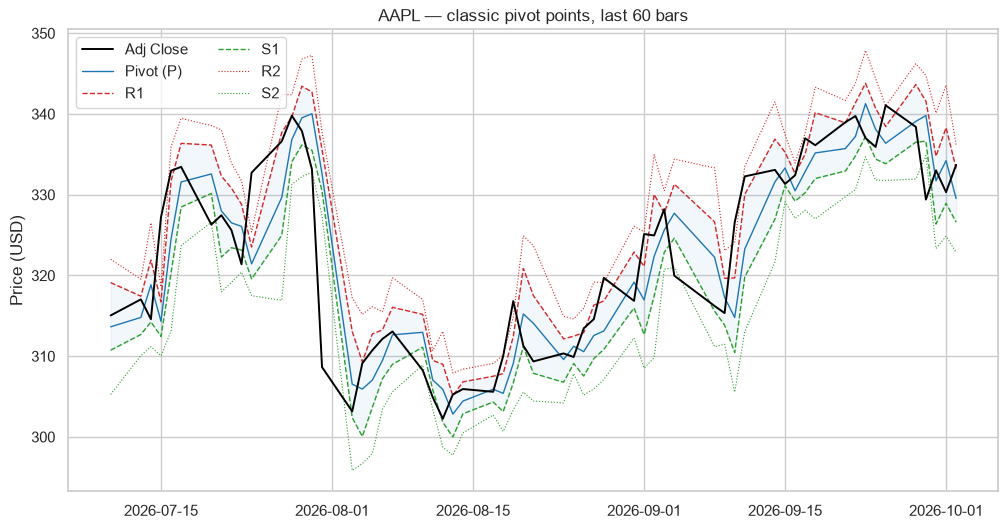

In [9]:
recent_close = close.iloc[-60:]
recent_pp = pp.iloc[-60:]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(recent_close.index, recent_close, color="black", lw=1.4, label="Adj Close", zorder=3)
ax.plot(recent_pp.index, recent_pp["pivot"], color="tab:blue", lw=1.0, label="Pivot (P)")
ax.plot(recent_pp.index, recent_pp["r1"], color="tab:red", lw=1.0, ls="--", label="R1")
ax.plot(recent_pp.index, recent_pp["s1"], color="tab:green", lw=1.0, ls="--", label="S1")
ax.plot(recent_pp.index, recent_pp["r2"], color="tab:red", lw=0.8, ls=":", label="R2")
ax.plot(recent_pp.index, recent_pp["s2"], color="tab:green", lw=0.8, ls=":", label="S2")
ax.fill_between(recent_pp.index, recent_pp["s1"], recent_pp["r1"], color="tab:blue", alpha=0.06)

ax.set_title(f"{ticker} — classic pivot points, last 60 bars")
ax.set_ylabel("Price (USD)")
ax.legend(loc="upper left", ncols=2)
plt.show()

## 5. From levels to a trade plan

None of this says *which way* price will go. What it does say is where the **levels** are, and that is enough to
place a trade with defined risk:

- **Entry** — a pullback into the 38.2%–61.8% zone, or a hold of S1 / a break above R1.
- **Stop** — below the invalidation point: the 78.6% level or the swing low. If price gets there, the leg is
  broken and the idea is wrong — that, not the dollar loss, is what the stop encodes.
- **Target** — the extension (127.2%/161.8%) or R2, whichever comes first.

The table below puts those candidates side by side with their distance from the last close, so the
**reward-to-risk** is explicit. Concretely: risk = entry − stop, reward = target − entry.

In [10]:
plan = pd.DataFrame(
    {
        "level": ["78.6% retr. (stop zone)", "61.8% retr.", "50% retr.", "38.2% retr.",
                  "last close", "swing high", "pivot R1", "ext 127.2%", "ext 161.8%"],
        "price": [levels["0.786"], levels["0.618"], levels["0.5"], levels["0.382"],
                  last_close, leg["high"], today["r1"], extensions["1.272"], extensions["1.618"]],
    }
)
plan["vs last close"] = plan["price"] - last_close
plan["vs last close %"] = plan["vs last close"] / last_close * 100

entry, stop, target = levels["0.618"], levels["0.786"], extensions["1.272"]
print(f"example plan: entry {entry:,.2f} | stop {stop:,.2f} | target {target:,.2f}")
print(f"risk   : {entry - stop:,.2f} points")
print(f"reward : {target - entry:,.2f} points")
print(f"R:R    : {(target - entry) / (entry - stop):,.2f} : 1")

plan

example plan: entry 325.17 | stop 320.85 | target 348.07
risk   : 4.32 points
reward : 22.90 points
R:R    : 5.30 : 1


,level,price,vs last close,vs last close %
0,78.6% retr. (stop zone),320.85,-12.84,-3.85
1,61.8% retr.,325.17,-8.52,-2.55
2,50% retr.,328.21,-5.49,-1.64
3,38.2% retr.,331.24,-2.45,-0.73
4,last close,333.69,0.00,0.00
5,swing high,341.07,7.38,2.21
6,pivot R1,333.26,-0.43,-0.13
7,ext 127.2%,348.07,14.38,4.31
8,ext 161.8%,356.97,23.28,6.98


## 6. The limits, stated plainly

- **Swings are lagging.** They are confirmed `window` bars after the fact, so a level is only as good as the leg it was drawn on. Change `window` and the leg moves.
- **Fibonacci ratios are conventions, not physics.** `38.2%` and `61.8%` come from the golden ratio; `50%` is just a round number. Why they sometimes "work" is a story about crowd attention and order placement.
- **Retracement is measured, not predicted.** The levels say *where a pullback would be interesting*; they do not say a pullback will happen or stop there.
- **Pivots assume the last session's range matters today.** After a gap, news, or an earnings report, that assumption is the first thing to break.
- **A level is a zone, not a line.** Two prices that differ by a few cents are the same level to a human trader.
- **Nothing here is a signal to buy.** It is a framework for placing a stop and a target — position sizing and the decision itself are still yours.

> Educational analysis only — not financial advice.

## Recap

- `swing_highs_lows` flags strict local extremes (ties ignored) and is **confirmed with a lag**; `recent_swing` reduces those to the last completed low → high leg.
- `fibonacci_levels` measures retracement **inside** the leg (`high − r·span`), `fibonacci_extensions` projects targets **beyond** it (`high + (r−1)·span`).
- `pivot_points` builds P/R1–R3/S1–S3 from the **previous** bar's high/low/close, so today's levels never use today's data.
- Levels give you three concrete prices: an entry zone, an invalidation point for the stop, and a target — and the reward-to-risk follows from them.
- Every one of these is an *observation about where price has been*, and a place to watch. None of them predicts.

**Try this:** set `window = 3` and then `window = 10` and re-run — how much do the leg, the Fibonacci levels and
the example plan move? Then change `ticker` to `"MSFT"` (or a much more volatile name) and repeat; check
`period="2y"` as well, where the last leg may be months old. Finally, replace the 6-month history with the
one-month Google Finance frame from notebook 13 (`google_history(ticker, exchange="NASDAQ")` → build the OHLC
frame) and see which of these levels you can still compute — and which the short window makes meaningless.